# MatRisk AI – Commodity Prediction using Material Science

## Overview
This project integrates material science and financial data to predict commodity prices and analyze material quality.

We solve:
- Task 1: Material Quality Index (MQI) prediction
- Task 2: Commodity price prediction using cross-domain features
- Bonus: Cost-aware material evaluation

This approach demonstrates how material properties influence financial markets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
ds1 = pd.read_csv("DS1_material_properties_5500.csv")

ds1.head()

,material_id,formula,n_elements,crystal_system,spacegroup_number,category,formation_energy_per_atom_eV,energy_above_hull_eV,band_gap_eV,is_metal,bulk_modulus_GPa,shear_modulus_GPa,poisson_ratio,density_g_cm3,nsites,volume_A3,melting_point_K,is_stable
0,mp-121959,Ta3Au3H2,3,hexagonal,185,Chalcogenide,-0.6329,0.0175,1.940,0,26.87,13.47,0.2918,4.343,2,96.38,1142.0,1
1,mp-23248,Al3Rh4W3,3,hexagonal,171,Alloy,-1.2275,0.2124,0.000,1,50.30,33.94,0.2326,6.757,4,365.02,1244.0,0
2,mp-526982,Pd3Te3,2,cubic,227,Metal,0.1265,0.0993,0.000,1,256.03,125.93,0.2849,10.501,4,642.24,1178.0,0
3,mp-984775,Ne4Cd4,2,tetragonal,81,Nitride,-0.4655,0.0534,1.830,0,461.87,233.17,0.2888,1.754,32,820.52,1130.0,0
4,mp-965909,Al4Rh,2,cubic,202,Nitride,-0.6142,0.0501,1.264,0,187.79,148.00,0.1900,3.360,2,87.85,306.0,0


In [5]:
print(ds1.columns)

Index(['material_id', 'formula', 'n_elements', 'crystal_system',
       'spacegroup_number', 'category', 'formation_energy_per_atom_eV',
       'energy_above_hull_eV', 'band_gap_eV', 'is_metal', 'bulk_modulus_GPa',
       'shear_modulus_GPa', 'poisson_ratio', 'density_g_cm3', 'nsites',
       'volume_A3', 'melting_point_K', 'is_stable'],
      dtype='object')


In [ ]:


ds1['MQI'] = (
    ds1['bulk_modulus_GPa'] +
    ds1['shear_modulus_GPa'] +
    ds1['density_g_cm3']
) / 3


ds1[['bulk_modulus_GPa', 'shear_modulus_GPa', 'density_g_cm3', 'MQI']].head()

,bulk_modulus_GPa,shear_modulus_GPa,density_g_cm3,MQI
0,26.87,13.47,4.343,14.894333
1,50.30,33.94,6.757,30.332333
2,256.03,125.93,10.501,130.820333
3,461.87,233.17,1.754,232.264667
4,187.79,148.00,3.360,113.050000


In [7]:
# Select only numeric features
X1 = ds1.select_dtypes(include=[np.number])

# Remove target column
X1 = X1.drop(['MQI'], axis=1)

# Target
y1 = ds1['MQI']

# Handle missing values
X1 = X1.fillna(X1.mean())
y1 = y1.fillna(y1.mean())

In [8]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

In [9]:
model1 = RandomForestRegressor(n_estimators=50, random_state=42)

model1.fit(X1_train, y1_train)

RandomForestRegressor(n_estimators=50, random_state=42)

In [10]:
y1_pred = model1.predict(X1_test)

In [11]:
print("Task 1 MSE:", mean_squared_error(y1_test, y1_pred))
print("Task 1 R2 Score:", r2_score(y1_test, y1_pred))

Task 1 MSE: 1.4773081982431864
Task 1 R2 Score: 0.9992371540325637


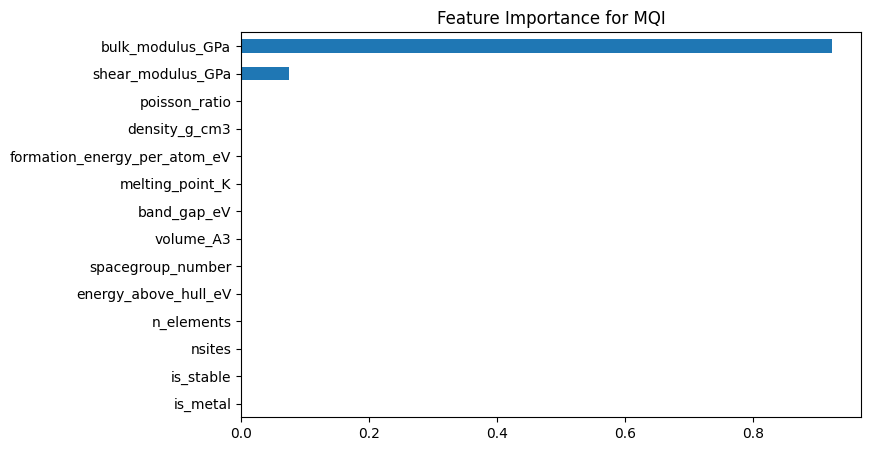

In [12]:
importance1 = model1.feature_importances_
features1 = X1.columns

feat_imp1 = pd.Series(importance1, index=features1).sort_values()

plt.figure(figsize=(8,5))
feat_imp1.plot(kind='barh')
plt.title("Feature Importance for MQI")
plt.show()

# Task 2: Commodity Price Prediction using Cross-Domain Features

## Objective
The goal of Task 2 is to predict commodity prices by integrating financial data with material science signals.

## Approach
We use:
- DS2: Commodity price dataset (financial indicators like returns, volatility, RSI)
- DS3: Cross-domain features (Material Quality Index, supply disruption probability, substitution elasticity)

By combining these datasets, we aim to understand how material properties and supply dynamics influence commodity price movements.

## Key Questions Addressed
- Do changes in material quality (MQI) affect commodity prices?
- Can supply disruption probabilities predict market volatility?
- How does substitution elasticity impact demand cycles?

This integration allows us to build a more intelligent and realistic prediction model.

In [14]:
ds2 = pd.read_csv("DS2_commodity_prices_10yr.csv")
ds3 = pd.read_csv("DS3_crossdomain_features_daily.csv")